# Langfuse Metrics Dashboard — Compliance Pipeline

**Purpose:** Visualize production metrics fetched from Langfuse via the `/api/v1/metrics/summary` endpoint.

**Run periodically** (e.g., weekly) after data has accumulated in Langfuse.
Override the date range via env vars `METRICS_FROM` and `METRICS_TO` (ISO date strings).

In [3]:
import json
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from dotenv import load_dotenv

load_dotenv()

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "scripts"))
from metrics_lib import get_metrics

In [4]:
from_date = os.getenv("METRICS_FROM", (datetime.now() - timedelta(days=30)).date().isoformat())
to_date = os.getenv("METRICS_TO", datetime.now().date().isoformat())

raw = get_metrics(from_date, to_date)

# Normalizar al schema que espera el resto del notebook.
# La lib devuelve risk_score_avg/p50/p95 sueltos; el notebook espera un sub-dict "risk_score".
summary = {
    **raw,
    "risk_score": {
        "avg": raw.get("risk_score_avg"),
        "p25": None,   # no disponible en la lib
        "p50": raw.get("risk_score_p50"),
        "p75": None,   # no disponible en la lib
        "p95": raw.get("risk_score_p95"),
    },
}

print(json.dumps(summary, indent=2))

  [latency_p95_ms] iniciando...
  [latency_p95_ms] ok: 30994.6
  [avg_cost_per_alert_usd] iniciando...
  [avg_cost_per_alert_usd] ok: 0.00059992812478125
  [avg_tokens_per_alert] iniciando...
  [avg_tokens_per_alert] ok: 2210.421875
  [escalation_rate] iniciando...
  [escalation_rate] ok: 0.7619047619047619
  [avg_confidence] iniciando...
  [avg_confidence] ok: 0.9023809523809525
  [auto_dismissed_rate] iniciando...
  [auto_dismissed_rate] ok: 0.23809523809523808
  [error_rate] iniciando...
  [error_rate] ok: 0
  [risk_score_avg] iniciando...
  [risk_score_avg] ok: 5.619047619047619
  [risk_score_p50] iniciando...
  [risk_score_p50] ok: 7
  [risk_score_p95] iniciando...
  [risk_score_p95] ok: 7
  fetching latency_by_agent...
  latency_by_agent ok: {'research': 3106.8499999999985, 'risk_analyzer': 4334.15, 'decision_agent': 22892.549999999996}
  fetching total_traces...
  total_traces ok: 32


{
  "period": {
    "from": "2026-04-22",
    "to": "2026-05-22"
  },
  "latency_p95_ms": 30994.6,
  "avg_cost_per_alert_usd": 0.00059992812478125,
  "avg_tokens_per_alert": 2210.421875,
  "escalation_rate": 0.7619047619047619,
  "avg_confidence": 0.9023809523809525,
  "auto_dismissed_rate": 0.23809523809523808,
  "error_rate": 0,
  "risk_score_avg": 5.619047619047619,
  "risk_score_p50": 7,
  "risk_score_p95": 7,
  "latency_by_agent": {
    "research": 3106.8499999999985,
    "risk_analyzer": 4334.15,
    "decision_agent": 22892.549999999996
  },
  "total_traces": 32,
  "risk_score": {
    "avg": 5.619047619047619,
    "p25": null,
    "p50": 7,
    "p75": null,
    "p95": 7
  }
}


In [5]:
# Celda — guardar snapshot
import json
snapshot_path = "metrics_snapshot_dev.json"
with open(snapshot_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"Guardado en {snapshot_path}")

Guardado en metrics_snapshot_dev.json


In [6]:
# Celda — cargar snapshot
import json
snapshot_path = "metrics_snapshot_dev.json"
with open(snapshot_path) as f:
    summary = json.load(f)
print(f"Cargado desde {snapshot_path}")

Cargado desde metrics_snapshot_dev.json


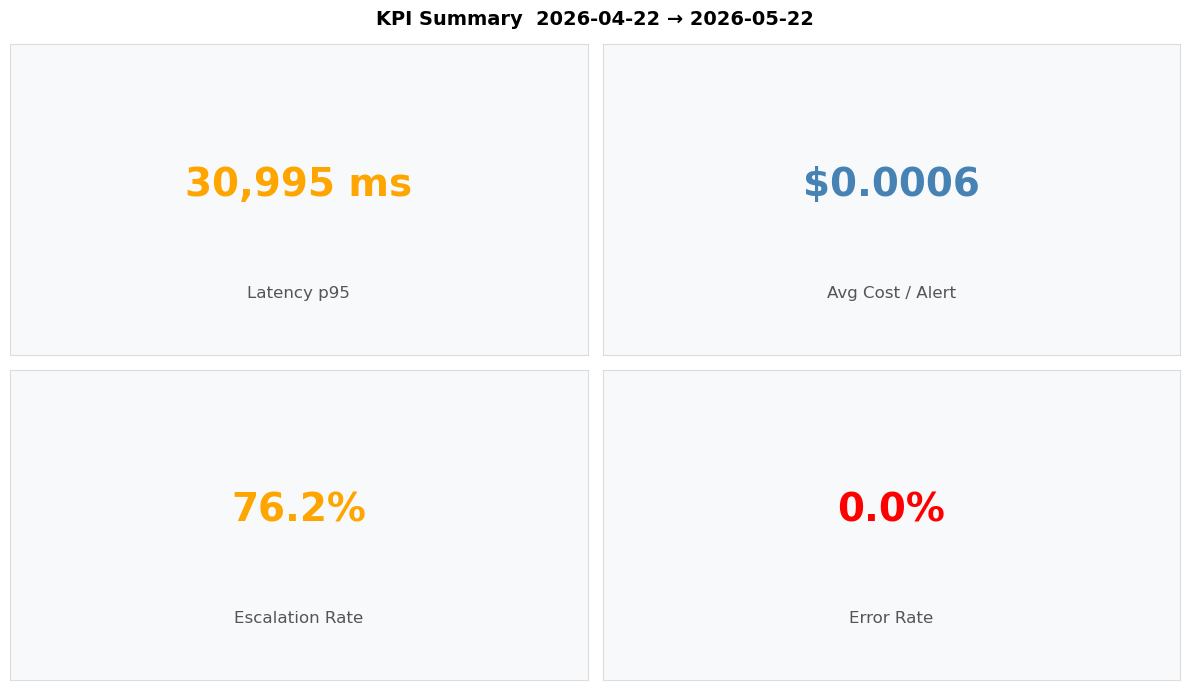

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle(f"KPI Summary  {from_date} → {to_date}", fontsize=14, fontweight="bold")

latency = summary.get("latency_p95_ms")
cost = summary.get("avg_cost_per_alert_usd")
escalation = summary.get("escalation_rate")
error_rate = summary.get("error_rate")

def _latency_color(v):
    if v is None:
        return "gray"
    return "green" if v < 30000 else ("orange" if v < 60000 else "red")

def _escalation_color(v):
    if v is None:
        return "gray"
    return "green" if 0.10 <= v <= 0.20 else "orange"

cards = [
    (axes[0, 0], "Latency p95", f"{latency:,.0f} ms" if latency is not None else "N/A", _latency_color(latency)),
    (axes[0, 1], "Avg Cost / Alert", f"${cost:.4f}" if cost is not None else "N/A", "steelblue"),
    (axes[1, 0], "Escalation Rate", f"{escalation:.1%}" if escalation is not None else "N/A", _escalation_color(escalation)),
    (axes[1, 1], "Error Rate", f"{error_rate:.1%}" if error_rate is not None else "N/A", "green" if (error_rate or 1) < 0.01 else "red"),
]

for ax, label, value, color in cards:
    ax.set_facecolor("#f8f9fa")
    ax.text(0.5, 0.55, value, ha="center", va="center", fontsize=28, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha="center", va="center", fontsize=12, color="#555", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#ddd")

plt.tight_layout()
plt.show()

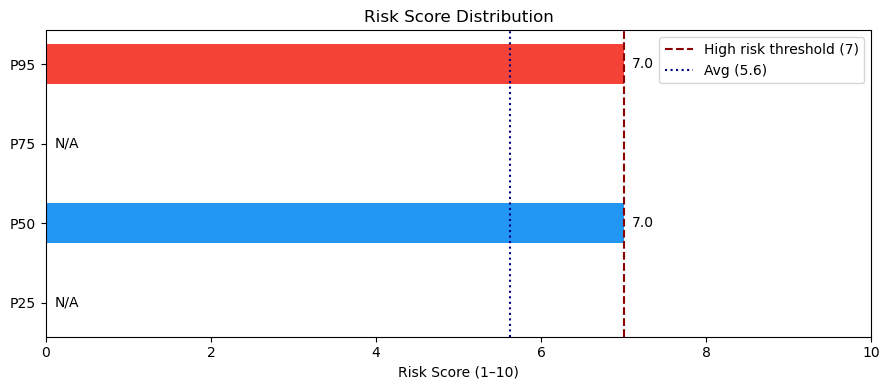

In [8]:
rs = summary.get("risk_score", {})
percentiles = ["p25", "p50", "p75", "p95"]
values = [rs.get(p) for p in percentiles]

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4CAF50", "#2196F3", "#FF9800", "#F44336"]

bars = ax.barh(
    [p.upper() for p in percentiles],
    [v if v is not None else 0 for v in values],
    color=colors,
    height=0.5,
)

ax.axvline(x=7, color="darkred", linestyle="--", linewidth=1.5, label="High risk threshold (7)")
ax.set_xlabel("Risk Score (1–10)")
ax.set_title("Risk Score Distribution")
ax.set_xlim(0, 10)
ax.legend()

for bar, val in zip(bars, values):
    label = f"{val:.1f}" if val is not None else "N/A"
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, label, va="center", fontsize=10)

if rs.get("avg") is not None:
    ax.axvline(x=rs["avg"], color="navy", linestyle=":", linewidth=1.5, label=f"Avg ({rs['avg']:.1f})")
    ax.legend()

plt.tight_layout()
plt.show()

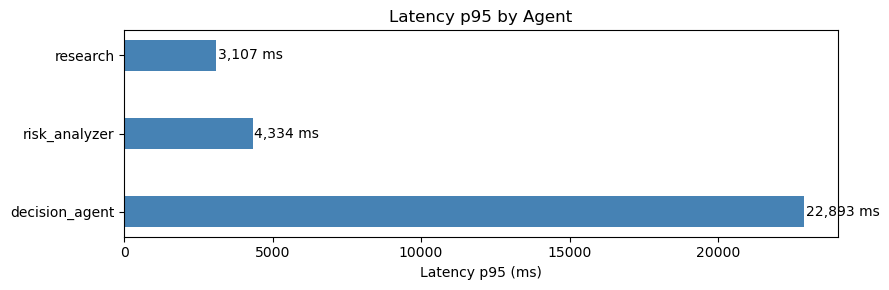

In [9]:
agent_data = summary.get("latency_by_agent", {})
agents = [(k, v) for k, v in agent_data.items() if v is not None]
agents.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(9, 3))

if agents:
    names, latencies = zip(*agents)
    ax.barh(names, latencies, color="steelblue", height=0.4)
    ax.set_xlabel("Latency p95 (ms)")
    for i, v in enumerate(latencies):
        ax.text(v + 50, i, f"{v:,.0f} ms", va="center", fontsize=10)
else:
    ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes, fontsize=12, color="gray")

ax.set_title("Latency p95 by Agent")
plt.tight_layout()
plt.show()

## Metrics Available Directly in Langfuse Cloud Dashboard

| Metric | Dashboard Location |
|--------|--------------------|
| Trace volume over time | Dashboard → Trace volume |
| Cost over time by model | Dashboard → Cost chart |
| Score distributions | Scores → Score Analytics |
| Per-trace timeline | Traces → click any trace |
| Token usage per generation | Traces → Generations tab |

> Screenshots → `docs/observability/`

In [10]:
today = datetime.now().date().isoformat()
snapshot_path = f"metrics_snapshot_{today}.json"

with open(snapshot_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved snapshot to {snapshot_path}")

Saved snapshot to metrics_snapshot_2026-05-22.json
